<a href="https://colab.research.google.com/github/HakumenWorld/data-science-2026/blob/main/Pertemuan12_Febi_Kristiana_240401010231.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aktivitas Hands-on: Market Basket Analysis & Rekomendasi Produk
**Mata Kuliah:** Pengantar Data Science  
**Pertemuan:** 12  
**Nama:** Febi Kristiana  
**NIM:** 240401010231

Notebook ini disusun mengikuti bagian **Aktivitas Hands-on** pada modul pertemuan 12.  
Jalankan sel secara berurutan dari atas ke bawah di Google Colab.

## Langkah 0 — Buat File Jupyter Notebook Baru
Nama file sesuai modul: `Pertemuan12_[Nama]_[NIM].ipynb`

Aktivitas menggunakan dua dataset sintetis: transaksi belanja dan katalog produk.
Tahapannya mencakup **Apriori**, **Association Rules**, dan rekomendasi
**Content-Based Filtering**.

## Persiapan Library

In [1]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "mlxtend"
])

print("mlxtend siap digunakan.")

mlxtend siap digunakan.


## Langkah 1 — Generate & Eksplorasi Dataset Transaksi

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

produk = [
    "Roti", "Selai", "Susu", "Sereal", "Telur",
    "Keju", "Kopi", "Gula", "Teh", "Mentega"
]

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola: Roti sering bersama Selai
for i in range(0, 20):
    if "Roti" in transaksi[i] and "Selai" not in transaksi[i]:
        transaksi[i].append("Selai")

print("Contoh transaksi:", transaksi[:3])
print("Jumlah transaksi:", len(transaksi))

Contoh transaksi: [[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai'], [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')], [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]]
Jumlah transaksi: 50


,Produk,Frekuensi
4,Selai,26
5,Teh,23
2,Mentega,21
7,Telur,18
0,Keju,17
1,Roti,16
3,Kopi,16
6,Susu,16
8,Gula,16
9,Sereal,9


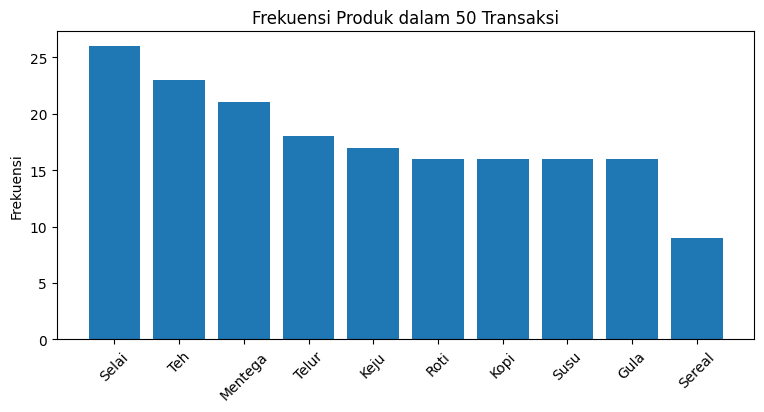

In [3]:
# Eksplorasi frekuensi tiap produk
from collections import Counter

frekuensi = Counter(item for trx in transaksi for item in trx)
frekuensi_df = (
    pd.DataFrame(frekuensi.items(), columns=["Produk", "Frekuensi"])
    .sort_values("Frekuensi", ascending=False)
)

display(frekuensi_df)

plt.figure(figsize=(9, 4))
plt.bar(frekuensi_df["Produk"], frekuensi_df["Frekuensi"])
plt.xticks(rotation=45)
plt.ylabel("Frekuensi")
plt.title("Frekuensi Produk dalam 50 Transaksi")
plt.show()

## Langkah 2 — One-Hot Encoding Transaksi

In [4]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df = pd.DataFrame(te_ary, columns=te.columns_)

display(df.head())

,Gula,Keju,Kopi,Mentega,Roti,Selai,Sereal,Susu,Teh,Telur
0,False,True,True,True,True,True,False,False,False,False
1,False,False,True,True,True,True,False,False,True,False
2,False,False,True,False,False,False,False,True,True,False
3,False,True,False,False,False,True,False,False,True,True
4,True,True,False,True,False,False,False,True,False,False


## Langkah 3 — Cari Frequent Itemset dengan Apriori

In [5]:
from mlxtend.frequent_patterns import apriori

for ms in [0.05, 0.1, 0.2]:
    freq = apriori(df, min_support=ms, use_colnames=True)
    print(f"min_support={ms}: {len(freq)} itemset ditemukan")

freq_items = apriori(df, min_support=0.1, use_colnames=True)
freq_items = freq_items.sort_values("support", ascending=False)

print("\n10 frequent itemset teratas:")
display(freq_items.head(10))

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan

10 frequent itemset teratas:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
5,0.52,(Selai)
8,0.46,(Teh)
3,0.42,(Mentega)
9,0.36,(Telur)
1,0.34,(Keju)
0,0.32,(Gula)
2,0.32,(Kopi)
4,0.32,(Roti)
7,0.32,(Susu)
36,0.24,"(Selai, Teh)"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Langkah 4 — Bentuk & Saring Aturan Asosiasi

In [6]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.5
)

rules = rules[rules["lift"] > 1].sort_values("lift", ascending=False)

print("10 aturan dengan Lift tertinggi:")
display(
    rules[
        ["antecedents", "consequents", "support", "confidence", "lift"]
    ].head(10)
)

10 aturan dengan Lift tertinggi:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
10,"(Teh, Keju)",(Telur),0.12,0.857143,2.380952
13,"(Mentega, Selai)",(Kopi),0.10,0.625000,1.953125
11,"(Roti, Gula)",(Selai),0.10,1.000000,1.923077
7,(Sereal),(Mentega),0.14,0.777778,1.851852
9,"(Teh, Telur)",(Keju),0.12,0.600000,1.764706
15,"(Selai, Kopi)",(Mentega),0.10,0.714286,1.700680
8,"(Keju, Telur)",(Teh),0.12,0.750000,1.630435
12,"(Gula, Selai)",(Roti),0.10,0.500000,1.562500
14,"(Mentega, Kopi)",(Selai),0.10,0.714286,1.373626
1,(Roti),(Selai),0.22,0.687500,1.322115


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
if len(rules) > 0:
    aturan_terkuat = rules.iloc[0]
    print("Aturan terkuat:")
    print("Antecedents :", set(aturan_terkuat["antecedents"]))
    print("Consequents :", set(aturan_terkuat["consequents"]))
    print(f"Support     : {aturan_terkuat['support']:.3f}")
    print(f"Confidence  : {aturan_terkuat['confidence']:.3f}")
    print(f"Lift        : {aturan_terkuat['lift']:.3f}")
else:
    print("Belum ada aturan yang lolos filter. Coba turunkan min_support/min_threshold.")

Aturan terkuat:
Antecedents : {np.str_('Teh'), np.str_('Keju')}
Consequents : {np.str_('Telur')}
Support     : 0.120
Confidence  : 0.857
Lift        : 2.381


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Interpretasi:** aturan dengan `lift > 1` menunjukkan hubungan positif.
Semakin tinggi nilai lift, semakin kuat kecenderungan kedua item muncul bersama dibandingkan
jika keduanya independen.

## Langkah 5 — Rekomender Sederhana dengan Content-Based Filtering

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    "produk": produk,
    "kategori": [
        "Bakery", "Bakery", "Dairy", "Bakery", "Dairy",
        "Dairy", "Minuman", "Bumbu", "Minuman", "Dairy"
    ]
})

fitur = pd.get_dummies(katalog["kategori"])
sim_matrix = cosine_similarity(fitur)

def rekomendasi_serupa(nama_produk, top_n=3):
    idx_list = katalog.index[katalog["produk"] == nama_produk].tolist()
    if not idx_list:
        raise ValueError(f"Produk '{nama_produk}' tidak ditemukan di katalog.")

    idx = idx_list[0]
    skor = list(enumerate(sim_matrix[idx]))
    skor = sorted(skor, key=lambda x: x[1], reverse=True)
    skor = [s for s in skor if s[0] != idx][:top_n]

    return katalog.iloc[[i for i, _ in skor]]["produk"].tolist()

display(katalog)
print("Mirip dengan Roti:", rekomendasi_serupa("Roti"))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,produk,kategori
0,Roti,Bakery
1,Selai,Bakery
2,Susu,Dairy
3,Sereal,Bakery
4,Telur,Dairy
5,Keju,Dairy
6,Kopi,Minuman
7,Gula,Bumbu
8,Teh,Minuman
9,Mentega,Dairy


Mirip dengan Roti: ['Selai', 'Sereal', 'Susu']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Langkah 6 — Bandingkan Kedua Pendekatan

In [9]:
produk_target = "Roti"

rules_terkait = rules[
    rules["antecedents"].apply(lambda x: produk_target in x)
]

print("Rekomendasi dari Association Rules:")
if len(rules_terkait):
    display(rules_terkait[["consequents", "lift"]].head())
else:
    print("Tidak ada aturan terkait produk target pada threshold saat ini.")

print("Rekomendasi dari Content-Based:")
print(rekomendasi_serupa(produk_target))

Rekomendasi dari Association Rules:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,consequents,lift
11,(Selai),1.923077
1,(Selai),1.322115


Rekomendasi dari Content-Based:
['Selai', 'Sereal', 'Susu']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Analisis Perbandingan
- **Association Rules** menggunakan pola pembelian nyata pada transaksi.
- **Content-Based Filtering** menggunakan kemiripan atribut/kategori produk.
- Hasil keduanya tidak harus sama karena sumber informasi yang digunakan berbeda.
- Pendekatan **hybrid** dapat menggabungkan pola perilaku transaksi dan kemiripan konten.

## Kesimpulan

Dari aktivitas hands-on ini, kita telah mempelajari dua pendekatan utama untuk rekomendasi produk: **Market Basket Analysis** menggunakan algoritma Apriori dan Association Rules, serta **Content-Based Filtering**.

### Temuan Utama:
- **Market Basket Analysis** berhasil mengidentifikasi pola pembelian yang sering terjadi dan aturan asosiasi yang kuat antar produk (contoh: Roti dan Selai sering dibeli bersama). Metrik seperti `support`, `confidence`, dan `lift` membantu dalam mengevaluasi kekuatan dan validitas aturan.
- **Content-Based Filtering** merekomendasikan produk berdasarkan kemiripan atribut atau kategori. Pendekatan ini berguna ketika kita ingin merekomendasikan produk yang memiliki karakteristik serupa dengan produk yang diminati pengguna.

### Perbandingan Kedua Pendekatan:
- Hasil rekomendasi dari kedua metode bisa berbeda karena sumber informasi yang digunakan berbeda: Association Rules didasarkan pada perilaku transaksi nyata, sementara Content-Based Filtering didasarkan pada deskripsi atau kategori produk.
- Kombinasi dari kedua pendekatan (Hybrid Recommendation System) dapat memberikan rekomendasi yang lebih komprehensif dan akurat dengan memanfaatkan baik pola perilaku maupun kemiripan konten.

### Keterbatasan dan Pertanyaan Lebih Lanjut:
- Dataset yang digunakan adalah sintetis dan kecil (50 transaksi, 10 produk). Dalam skenario dunia nyata, ukuran dataset akan jauh lebih besar, memerlukan sumber daya komputasi yang lebih banyak dan penanganan data yang lebih canggih.
- Algoritma Apriori dan Association Rules bisa menjadi intensif secara komputasi untuk dataset yang sangat besar dan dengan banyak item. Pertimbangan untuk menggunakan alternatif yang lebih scalable mungkin diperlukan.
- Content-Based Filtering mungkin mengalami masalah 'cold-start' untuk produk baru tanpa atribut yang cukup, atau 'over-specialization' di mana hanya merekomendasikan item yang sangat mirip.
- Bagaimana cara mengukur efektivitas rekomendasi dalam skenario nyata? Metrik seperti Click-Through Rate (CTR) atau Conversion Rate (CR) perlu diimplementasikan.